<a href="https://colab.research.google.com/github/VilchisKarla/Procesos-Estocasticos/blob/main/Descomposicion_canonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descomposición en Matriz canónica
Vilchis García Karla Ivonne


---



In [84]:
#importar librerías necesarias
from networkx.classes.function import edges
import networkx as nx
import matplotlib.pyplot as plt
import sympy as sp
import numpy as np
import string

## Matriz P

In [85]:
#construcción de la matriz estocástica P
P=sp.Matrix([[1/4,0,0,0,0,0,3/4],[1/8,1/8,1/4,0,1/4,1/8,1/8],[0,0,2/5,1/5,2/5,0,0],[0,0,1/2,1/2,0,0,0],[0,0,0,1/2,1/2,0,0],[0,1/5,0,1/5,1/5,1/5,1/5],[4/5,0,0,0,0,0,1/5]])
sp.pprint(P)

⎡0.25     0     0     0    0      0    0.75 ⎤
⎢                                           ⎥
⎢0.125  0.125  0.25   0   0.25  0.125  0.125⎥
⎢                                           ⎥
⎢  0      0    0.4   0.2  0.4     0      0  ⎥
⎢                                           ⎥
⎢  0      0    0.5   0.5   0      0      0  ⎥
⎢                                           ⎥
⎢  0      0     0    0.5  0.5     0      0  ⎥
⎢                                           ⎥
⎢  0     0.2    0    0.2  0.2    0.2    0.2 ⎥
⎢                                           ⎥
⎣ 0.8     0     0     0    0      0     0.2 ⎦


## Diagrama de transiciones

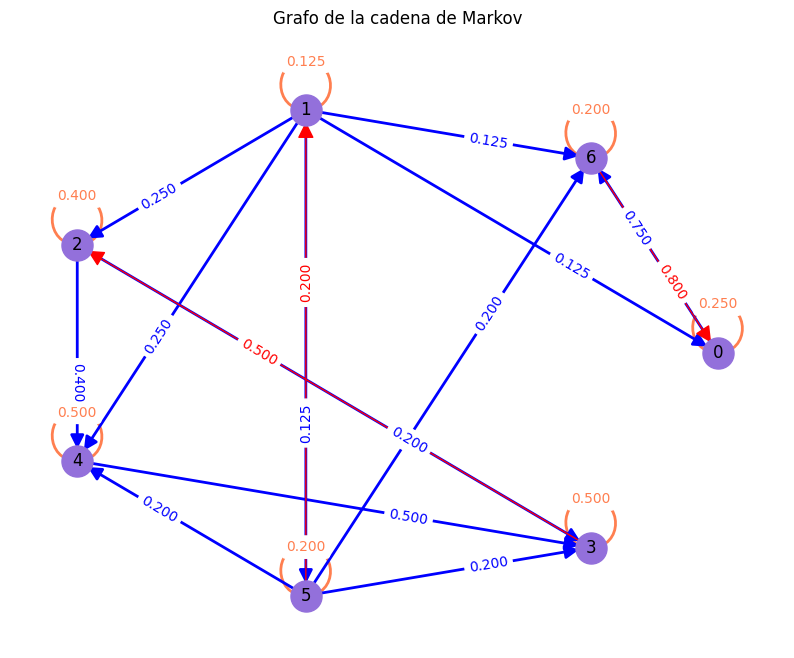

In [86]:
#función para generar el grafo
def construir_grafo(P):
    n = P.shape[0]
    G = nx.DiGraph()

    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                G.add_edge(i,j, weight=P[i, j])  #arcos con su peso

    return G

H=construir_grafo(P)

plt.figure(figsize=(10, 8))
pos = nx.circular_layout(H)

# Dibujar nodos
nx.draw_networkx_nodes(H, pos, node_size=500,node_color='mediumpurple')
nx.draw_networkx_labels(H, pos, font_size=12)

# Separar aristas
edges_ij = []  # i -> j
edges_ji = []  # j -> i
edges_ii = []  # i -> i
for (i, j) in H.edges():
    if H.has_edge(j, i) and i != j:
        # Si existe la opuesta
        if i < j:
            edges_ij.append((i, j))
            edges_ji.append((j, i))
    elif i==j:
        edges_ii.append((i, j))  # arco sin retorno
    else:
      edges_ij.append((i, j))
# Dibujar arcos con colores distintos
nx.draw_networkx_edges(
    H, pos,
    edgelist=edges_ii,
    edge_color='coral',
    arrowstyle='-|>',
    arrowsize=15,
    width=2
    #connectionstyle='arc3,rad=0.15' #hace las líneas curveadas
)

nx.draw_networkx_edges(
    H, pos,
    edgelist=edges_ij,
    edge_color='blue',
    arrowstyle='-|>',
    arrowsize=20,
    width=2
    #connectionstyle='arc3,rad=0.15'
)

nx.draw_networkx_edges(
    H, pos,
    edgelist=edges_ji,
    edge_color='red',
    arrowstyle='-|>',
    arrowsize=25,
    width=1
    #connectionstyle='arc3,rad=-0.15'
)

#  ETIQUETAS SEPARADAS POR COLOR

# Etiquetas coral
edge_labels_ii = {
    (i, j): f"{H[i][j]['weight']:.3f}"
    for (i, j) in edges_ii
}

nx.draw_networkx_edge_labels(
    H, pos,
    edge_labels=edge_labels_ii,
    font_color='coral',
    label_pos=0.65
)

# Etiquetas azules
edge_labels_ij = {
    (i, j): f"{H[i][j]['weight']:.3f}"
    for (i, j) in edges_ij
}

nx.draw_networkx_edge_labels(
    H, pos,
    edge_labels=edge_labels_ij,
    font_color='blue',
    label_pos=0.65
)

# Etiquetas rojas
edge_labels_ji = {
    (i, j): f"{H[i][j]['weight']:.3f}"
    for (i, j) in edges_ji
}

nx.draw_networkx_edge_labels(
    H, pos,
    edge_labels=edge_labels_ji,
    font_color='red',
    label_pos=0.65
)

plt.title("Grafo de la cadena de Markov")
plt.axis('off')
plt.show()

#2. Determine si la matriz tiene o no distribución límite

In [88]:

P20=P**20
P1000=P**1000
sp.pprint(P20.evalf(6))
print('\n\n')
sp.pprint(P1000.evalf(6))

⎡0.516132       0          0         0         0           0       0.483868⎤
⎢                                                                          ⎥
⎢0.172043  6.64804e-11  0.222222  0.266667  0.177778  6.64804e-11  0.16129 ⎥
⎢                                                                          ⎥
⎢   0           0       0.333333    0.4     0.266667       0          0    ⎥
⎢                                                                          ⎥
⎢   0           0       0.333333    0.4     0.266667       0          0    ⎥
⎢                                                                          ⎥
⎢   0           0       0.333333    0.4     0.266667       0          0    ⎥
⎢                                                                          ⎥
⎢0.172044  1.06369e-10  0.222222  0.266667  0.177778  1.06369e-10  0.161289⎥
⎢                                                                          ⎥
⎣0.516126       0          0         0         0           0       0.483874⎦

Se observa que la matriz no es regular, dado que para ninguna potencia de P todas sus entradas son positivas para algún $n\geq1$, por lo que **no tiene distrobución límite**

# 3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.

## Descomposición canónica de la matriz

Identificando las clases:

$$\{b,f\}$$
$$\{g,a\}$$
$$\{c,d,e\}$$

Se clasifican los estados:

**Transitorios:**
$$T=\{b,f\}$$
**Recurrentes**
$$R_1=\{g,a\}$$
$$R_2=\{c,d,e\}$$

se reescribe la matriz donde las columnas se llenan $i=[\text{T},R_1,\cdots, R_m]$

Y las filas: $j=[\text{T}, R_1 ,\cdots, R_m]$

Quedando la siguiente Matriz:

In [89]:
P1=sp.Matrix([[1/8,1/8,1/8,1/8,1/4,0,1/4],[1/5,1/5,0,1/5,0,1/5,1/5],[0,0,1/4,3/4,0,0,0],[0,0,4/5,1/5,0,0,0],[0,0,0,0,2/5,1/5,2/5],[0,0,0,0,1/2,1/2,0],[0,0,0,0,0,1/2,1/2]])
sp.pprint(P1.evalf(3))

⎡0.125  0.125  0.125  0.125  0.25   0   0.25⎤
⎢                                           ⎥
⎢ 0.2    0.2     0     0.2    0    0.2  0.2 ⎥
⎢                                           ⎥
⎢  0      0    0.25   0.75    0     0    0  ⎥
⎢                                           ⎥
⎢  0      0     0.8    0.2    0     0    0  ⎥
⎢                                           ⎥
⎢  0      0      0      0    0.4   0.2  0.4 ⎥
⎢                                           ⎥
⎢  0      0      0      0    0.5   0.5   0  ⎥
⎢                                           ⎥
⎣  0      0      0      0     0    0.5  0.5 ⎦


## Límite de la potencia n-esima

In [90]:
PN=P1**1000
sp.pprint(PN.evalf(6))

⎡2.94027e-489  2.94027e-489  0.172043  0.16129   0.222222  0.266667  0.177778⎤
⎢                                                                            ⎥
⎢4.70444e-489  4.70444e-489  0.172043  0.16129   0.222222  0.266667  0.177778⎥
⎢                                                                            ⎥
⎢     0             0        0.516129  0.483871     0         0         0    ⎥
⎢                                                                            ⎥
⎢     0             0        0.516129  0.483871     0         0         0    ⎥
⎢                                                                            ⎥
⎢     0             0           0         0      0.333333    0.4     0.266667⎥
⎢                                                                            ⎥
⎢     0             0           0         0      0.333333    0.4     0.266667⎥
⎢                                                                            ⎥
⎣     0             0           0         0      0.3

## Distribuciones límite de las submatrices.

**Submatriz T**

In [91]:
T=sp.Matrix([[0.125,0.125],[0.2,0.2]])
sp.pprint(T)

⎡0.125  0.125⎤
⎢            ⎥
⎣ 0.2    0.2 ⎦


**Potencia de T**

In [92]:
PTN=T**1000
sp.pprint(PTN.evalf(6))

⎡2.94027e-489  2.94027e-489⎤
⎢                          ⎥
⎣4.70444e-489  4.70444e-489⎦


**submatriz R1**

In [93]:
PR1=sp.Matrix([[1/4,3/4],[4/5,1/5]])
sp.pprint(PR1)

⎡0.25  0.75⎤
⎢          ⎥
⎣0.8   0.2 ⎦


**Potencia de R1**

In [94]:
PR1N=PR1**1000
sp.pprint(PR1N.evalf(6))

⎡0.516129  0.483871⎤
⎢                  ⎥
⎣0.516129  0.483871⎦


**submatriz R2**

In [95]:
PR2=sp.Matrix([[2/5,1/5,2/5],[1/2,1/2,0],[0,1/2,1/2]])
sp.pprint(PR2)

⎡0.4  0.2  0.4⎤
⎢             ⎥
⎢0.5  0.5   0 ⎥
⎢             ⎥
⎣ 0   0.5  0.5⎦


**Potencia R2**

In [96]:
PR2N=PR2**1000
sp.pprint(PR2N.evalf(4))

⎡0.3333  0.4  0.2667⎤
⎢                   ⎥
⎢0.3333  0.4  0.2667⎥
⎢                   ⎥
⎣0.3333  0.4  0.2667⎦


#4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.

In [102]:
#función para identificar las clases
def clases_comunicacion(G):
    return list(nx.strongly_connected_components(G))

#función para definir si es clase cerrada
def es_cerrada(P, clase):
    for i in clase:
        for j in range(P.shape[0]):
            if j not in clase and P[i, j] > 0:
                return False
    return True
#función para construir la matriz canónica y separar por bloques transitorios y recurrentes
def reordenar_y_bloques(P):
    G = construir_grafo(P)
    clases = list(nx.strongly_connected_components(G))

    transitorios = []
    recurrentes = []

    # Separar clases
    for c in clases:
        if es_cerrada(P, c):
            recurrentes.append(sorted(list(c)))
        else:
            transitorios.append(sorted(list(c)))

    # Orden final
    orden = []

    for c in transitorios:
        orden.extend(c)

    for c in recurrentes:
        orden.extend(c)

    # Matriz reordenada
    P_new = P[np.ix_(orden, orden)]

    # EXTRAER BLOQUES

    # Tamaño de T
    size_T = sum(len(c) for c in transitorios)

    # Bloque
    if size_T > 0:
        T_block = P_new[:size_T, :size_T]
        print("\nMatriz T (transitoria):\n",'\n\n')
        sp.pprint(sp.Matrix(T_block))
    else:
        print("\nNo hay estados transientes")

    # Bloques R_i (cada clase recurrente)
    inicio = size_T

    for idx, clase in enumerate(recurrentes):
        size = len(clase)

        R_i = P_new[inicio:inicio+size, inicio:inicio+size]

        print(f"\nMatriz R_{idx+1} (clase {clase}):\n",'\n\n')
        sp.pprint(sp.Matrix(R_i))

        inicio += size

    return P_new, orden, transitorios, recurrentes

# SOLUCIÓN
P = np.array(P)

P_new, orden, T, R = reordenar_y_bloques(P)
etiquetas =['a', 'b', 'c', 'd', 'e', 'f', 'g']

print("\nClases transientes:", [[etiquetas[s] for s in c] for c in T])
print("Clases recurrentes:", [[etiquetas[s] for s in c] for c in R])
print("\nOrden de estados:", [etiquetas[s] for s in orden])
print("\nMatriz canónica:\n")
sp.pprint(sp.Matrix(P_new))


Matriz T (transitoria):
 


⎡0.125  0.125⎤
⎢            ⎥
⎣ 0.2    0.2 ⎦

Matriz R_1 (clase [0, 6]):
 


⎡0.25  0.75⎤
⎢          ⎥
⎣0.8   0.2 ⎦

Matriz R_2 (clase [2, 3, 4]):
 


⎡0.4  0.2  0.4⎤
⎢             ⎥
⎢0.5  0.5   0 ⎥
⎢             ⎥
⎣ 0   0.5  0.5⎦

Clases transientes: [['b', 'f']]
Clases recurrentes: [['a', 'g'], ['c', 'd', 'e']]

Orden de estados: ['b', 'f', 'a', 'g', 'c', 'd', 'e']

Matriz canónica:

⎡0.125  0.125  0.125  0.125  0.25   0   0.25⎤
⎢                                           ⎥
⎢ 0.2    0.2     0     0.2    0    0.2  0.2 ⎥
⎢                                           ⎥
⎢  0      0    0.25   0.75    0     0    0  ⎥
⎢                                           ⎥
⎢  0      0     0.8    0.2    0     0    0  ⎥
⎢                                           ⎥
⎢  0      0      0      0    0.4   0.2  0.4 ⎥
⎢                                           ⎥
⎢  0      0      0      0    0.5   0.5   0  ⎥
⎢                                           ⎥
⎣  0      0      0      0     